<a href="https://colab.research.google.com/github/parulgoell/ai-attendance-agent/blob/main/smart_parking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Assignments (Vehicle ID -> Spot (row, col)):
Vehicle 1 -> Spot (0, 0)
Vehicle 2 -> Spot (1, 1)
Vehicle 3 -> Spot (2, 2)
Vehicle 4 -> Spot (3, 3)
Vehicle 5 -> Spot (4, 4)
Vehicle 6 -> Spot (3, 1)
Vehicle 7 -> Spot (0, 3)


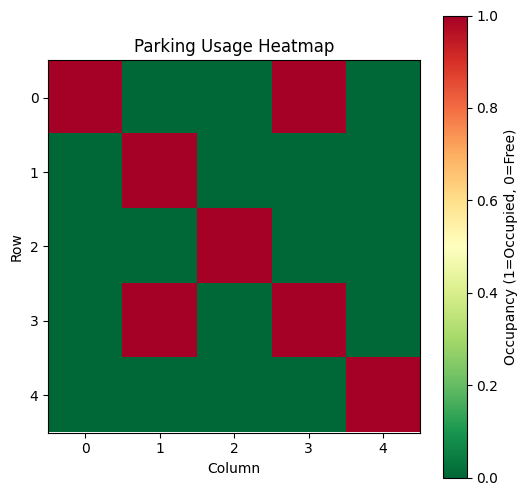

In [2]:
import numpy as np                              # For numerical operations and distance calculation
from scipy.optimize import linear_sum_assignment # Hungarian algorithm for optimal assignment
import matplotlib.pyplot as plt                 # For plotting heatmap of parking usage

# ---------------------------------------------------------
# Step 1: Define parking lot as a 5x5 grid of parking spots
# ---------------------------------------------------------

num_spots = 5                                   # Number of rows and columns (5x5 grid)
spots = [(i, j) for i in range(num_spots)       # Generate list of all parking spots
         for j in range(num_spots)]             # Each spot represented as (row, col) tuple

# ---------------------------------------------------------
# Step 2: Define vehicles and their entry positions
# ---------------------------------------------------------

vehicles = [
    {'id': 1, 'position': (0, 0)},              # Vehicle 1 entering at coordinate (0,0)
    {'id': 2, 'position': (1, 1)},              # Vehicle 2 entering at (1,1)
    {'id': 3, 'position': (2, 2)},              # Vehicle 3 entering at (2,2)
    {'id': 4, 'position': (3, 3)},              # Vehicle 4 entering at (3,3)
    {'id': 5, 'position': (4, 4)},              # Vehicle 5 entering at (4,4)
    {'id': 6, 'position': (3, 1)},              # Vehicle 6 entering at (3,1)
    {'id': 7, 'position': (0, 3)},              # Vehicle 7 entering at (0,3)
]

# ---------------------------------------------------------
# Step 3: Build cost matrix using Euclidean distances
# ---------------------------------------------------------

num_vehicles = len(vehicles)                    # Count how many vehicles we have

cost_matrix = np.zeros((num_vehicles,           # Create empty cost matrix (vehicles × spots)
                        len(spots)))            # Each cell = cost of assigning vehicle to spot

for v_idx, vehicle in enumerate(vehicles):      # Loop through each vehicle
    v_pos = vehicle['position']                 # Extract vehicle's entry position
    for s_idx, spot in enumerate(spots):        # Loop through every parking spot
        # Cost = Euclidean distance between vehicle position and spot position
        cost_matrix[v_idx, s_idx] = np.linalg.norm(np.array(v_pos) - np.array(spot))

# ---------------------------------------------------------
# Step 4: Use Hungarian Algorithm to find optimal assignment
# ---------------------------------------------------------

row_ind, col_ind = linear_sum_assignment(cost_matrix)  # Compute minimal-cost assignment

# Map each vehicle to its assigned parking spot
assignments = {vehicles[row]['id']: spots[col]         # Convert index mapping to readable output
               for row, col in zip(row_ind, col_ind)}

print("Assignments (Vehicle ID -> Spot (row, col)):")
for vid, spot in assignments.items():           # Print each assignment nicely
    print(f"Vehicle {vid} -> Spot {spot}")

# ---------------------------------------------------------
# Step 5: Create heatmap grid for parking usage visualization
# ---------------------------------------------------------

usage_grid = np.zeros((num_spots, num_spots))          # Create 5x5 grid initialized to 0 (all free)

for spot in assignments.values():                       # Each assigned spot becomes occupied
    usage_grid[spot[0], spot[1]] = 1                    # Mark that spot as occupied (1)

# ---------------------------------------------------------
# Visualize parking occupancy using heatmap
# ---------------------------------------------------------

plt.figure(figsize=(6, 6))                             # Set plot size
plt.imshow(usage_grid, cmap='RdYlGn_r', origin='upper') # Red=occupied, green=free
plt.colorbar(label='Occupancy (1=Occupied, 0=Free)')    # Add color scale legend
plt.title('Parking Usage Heatmap')                      # Title for the heatmap
plt.xlabel('Column')                                    # Label for x-axis
plt.ylabel('Row')                                       # Label for y-axis
plt.xticks(range(num_spots))                            # Set ticks for columns
plt.yticks(range(num_spots))                            # Set ticks for rows
plt.grid(False)                                         # Disable gridlines for cleaner view
plt.show()                                              # Display the final heatmap
